# CSV Bounding Box Visualization

This notebook visualizes bounding boxes from CSV annotations on chess board images.

**Dataset:** `data/raw/Chess Pieces Detection Image Dataset/Chess_pieces/`
**Source:** CSV annotations (ignoring YOLO OBB files)
**Filter:** Skipping annotations with class == "bishop"

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import random
import os

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Set up paths (relative paths from workspace root)
# Try multiple possible locations
possible_roots = [
    Path.cwd().parent,  # If running from notebooks/ directory
    Path.cwd(),         # If running from workspace root
]

DATA_ROOT = None
for root in possible_roots:
    test_path = root / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces"
    if test_path.exists():
        DATA_ROOT = test_path
        break

if DATA_ROOT is None:
    # Fallback: try relative to current directory
    DATA_ROOT = Path("data") / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces"

CSV_PATH = DATA_ROOT / "train" / "_annotations.csv"
IMAGES_DIR = DATA_ROOT / "train" / "images"

print(f"Current working directory: {Path.cwd()}")
print(f"Data root: {DATA_ROOT}")
print(f"CSV path: {CSV_PATH}")
print(f"Images directory: {IMAGES_DIR}")
print(f"CSV exists: {CSV_PATH.exists()}")
print(f"Images dir exists: {IMAGES_DIR.exists()}")

Current working directory: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411 Project/chessvision/notebooks
Data root: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411 Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Chess_pieces
CSV path: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411 Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Chess_pieces/train/_annotations.csv
Images directory: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411 Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Chess_pieces/train/images
CSV exists: True
Images dir exists: True


In [ ]:
# Load CSV annotations
df = pd.read_csv(CSV_PATH)

print(f"Total annotations: {len(df)}")
print(f"\nUnique images: {df['filename'].nunique()}")
print(f"\nClass distribution:")
print(df['class'].value_counts().sort_index())

# Filter out "bishop" class
df_filtered = df[df['class'] != 'bishop'].copy()
print(f"\nAfter filtering 'bishop': {len(df_filtered)} annotations")
print(f"Unique images after filtering: {df_filtered['filename'].nunique()}")

# Display first few rows
df_filtered.head()

Total annotations: 6324

Unique images: 606

Class distribution:
class
bishop             3
black-bishop     291
black-king       303
black-knight     423
black-pawn      1488
black-queen      186
black-rook       441
white-bishop     375
white-king       315
white-knight     420
white-pawn      1422
white-queen      243
white-rook       414
Name: count, dtype: int64

After filtering 'bishop': 6321 annotations
Unique images after filtering: 606


,filename,width,height,class,xmin,ymin,xmax,ymax
0,a8847f8fe8eaaa1c97bf83027a901760_jpg.rf.cb0f3b...,416,416,white-knight,170,233,200,303
1,a8847f8fe8eaaa1c97bf83027a901760_jpg.rf.cb0f3b...,416,416,white-king,46,80,81,169
2,a8847f8fe8eaaa1c97bf83027a901760_jpg.rf.cb0f3b...,416,416,white-queen,128,15,156,92
3,a8847f8fe8eaaa1c97bf83027a901760_jpg.rf.cb0f3b...,416,416,white-bishop,166,145,195,207
4,a8847f8fe8eaaa1c97bf83027a901760_jpg.rf.cb0f3b...,416,416,white-rook,162,31,189,86


In [ ]:
# Get unique image filenames
unique_images = df_filtered['filename'].unique()
print(f"Available images with non-bishop annotations: {len(unique_images)}")

# Randomly select 3 images
selected_images = random.sample(list(unique_images), min(3, len(unique_images)))
print(f"\nSelected images:")
for img in selected_images:
    print(f"  - {img}")

Available images with non-bishop annotations: 606

Selected images:
  - 76d01bada90581f55f1ae64c062cafcf_jpg.rf.f3d7a25fb4f47eb56b7affa5673c14f7.jpg
  - d67b5b9e900409b050dd9bd594f90709_jpg.rf.c8f40141d74f9737a0979fb96b6f34d2.jpg
  - 48e115dcbf1b3a67ca47a75a92da3f33_jpg.rf.957bf6dd4345aa7c771e116ba8273385.jpg


In [ ]:
def draw_bboxes_on_image(image_path, annotations_df, title="Chess Board with Bounding Boxes"):
    """
    Load an image and draw bounding boxes with class labels.

    Args:
        image_path: Path to the image file
        annotations_df: DataFrame with annotations for this image
        title: Title for the plot
    """
    # Load image
    img = Image.open(image_path)

    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.imshow(img)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

    # Color map for different classes
    colors = plt.cm.tab20(np.linspace(0, 1, annotations_df['class'].nunique()))
    class_to_color = {cls: colors[i] for i, cls in enumerate(annotations_df['class'].unique())}

    # Draw bounding boxes
    for _, row in annotations_df.iterrows():
        xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        class_name = row['class']

        # Create rectangle
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor=class_to_color[class_name],
            facecolor='none'
        )
        ax.add_patch(rect)

        # Add class label
        ax.text(
            xmin, ymin - 5,
            class_name,
            fontsize=10,
            fontweight='bold',
            color=class_to_color[class_name],
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=class_to_color[class_name])
        )

    plt.tight_layout()
    return fig


Image 1: 76d01bada90581f55f1ae64c062cafcf_jpg.rf.f3d7a25fb4f47eb56b7affa5673c14f7.jpg
Number of bounding boxes: 17
Classes present: black-bishop, black-king, black-pawn, black-rook, white-bishop, white-king, white-knight, white-pawn, white-queen, white-rook


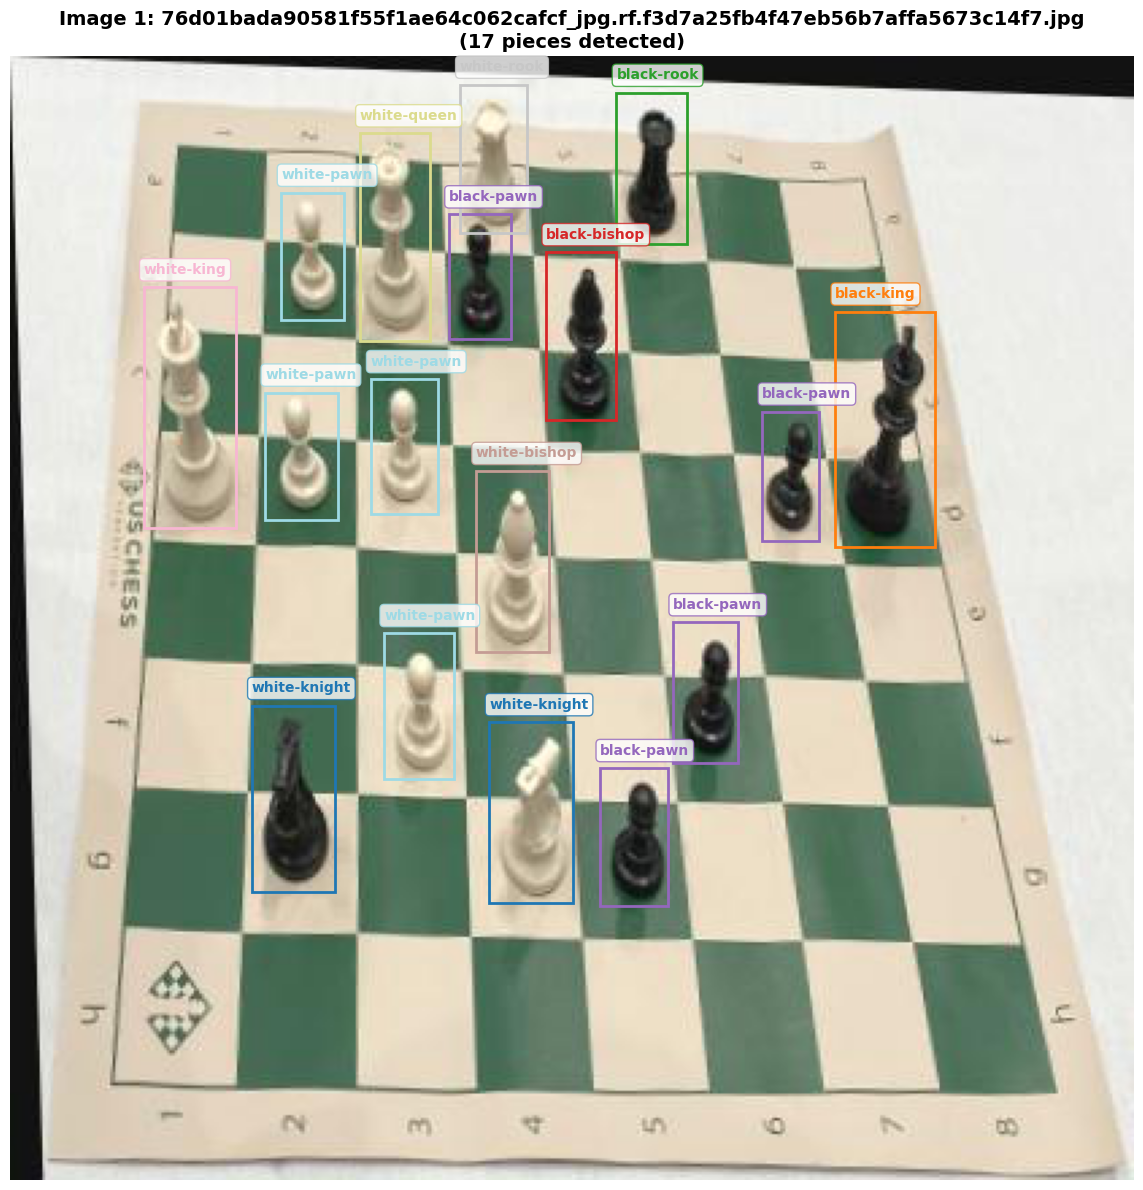


Image 2: d67b5b9e900409b050dd9bd594f90709_jpg.rf.c8f40141d74f9737a0979fb96b6f34d2.jpg
Number of bounding boxes: 1
Classes present: white-knight


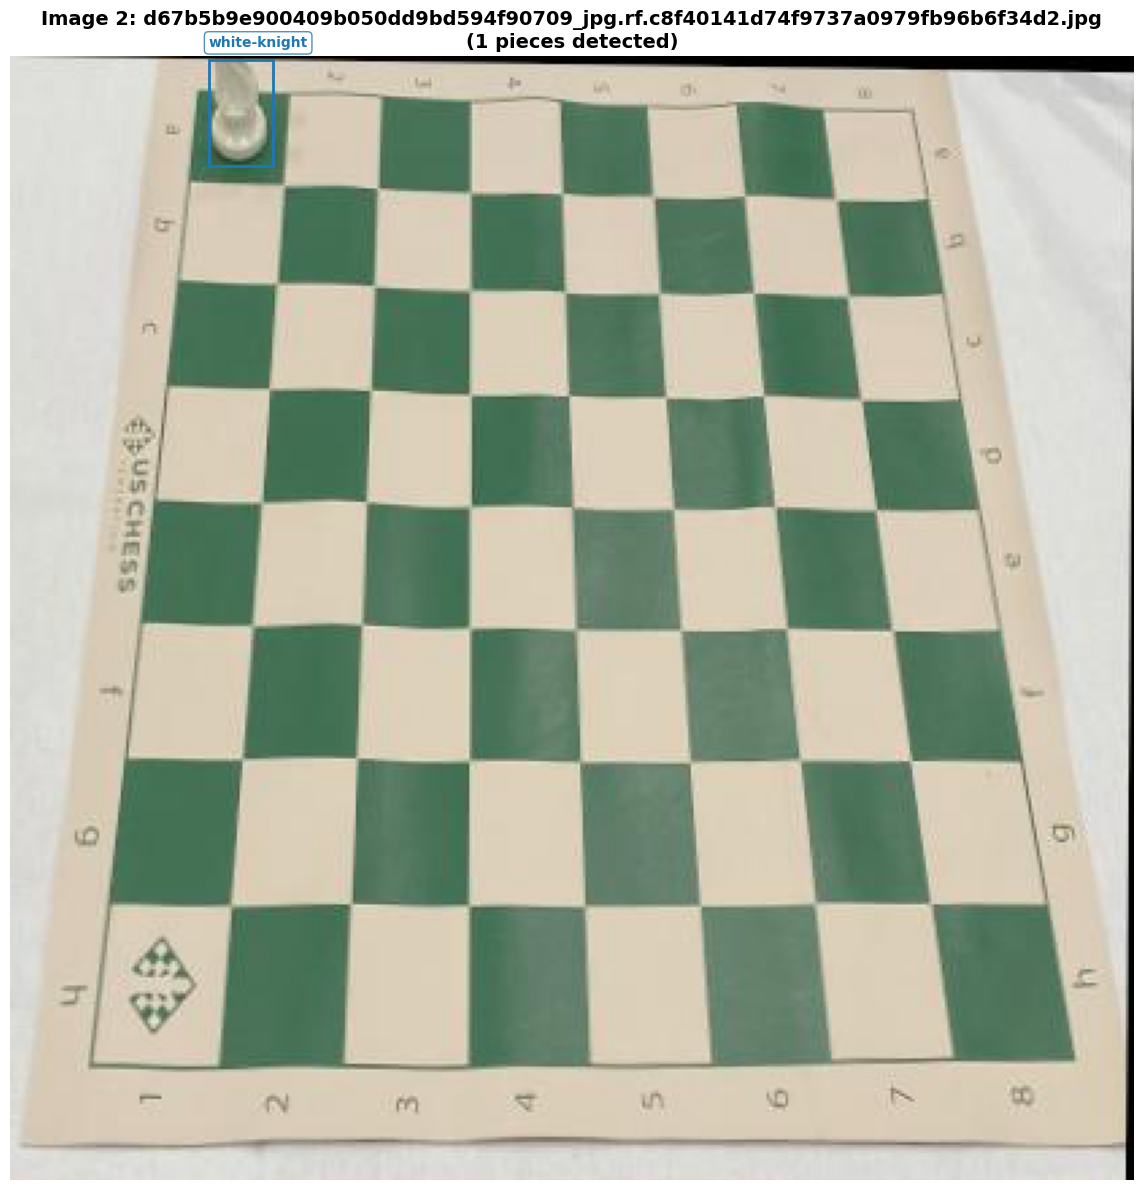


Image 3: 48e115dcbf1b3a67ca47a75a92da3f33_jpg.rf.957bf6dd4345aa7c771e116ba8273385.jpg
Number of bounding boxes: 1
Classes present: white-knight


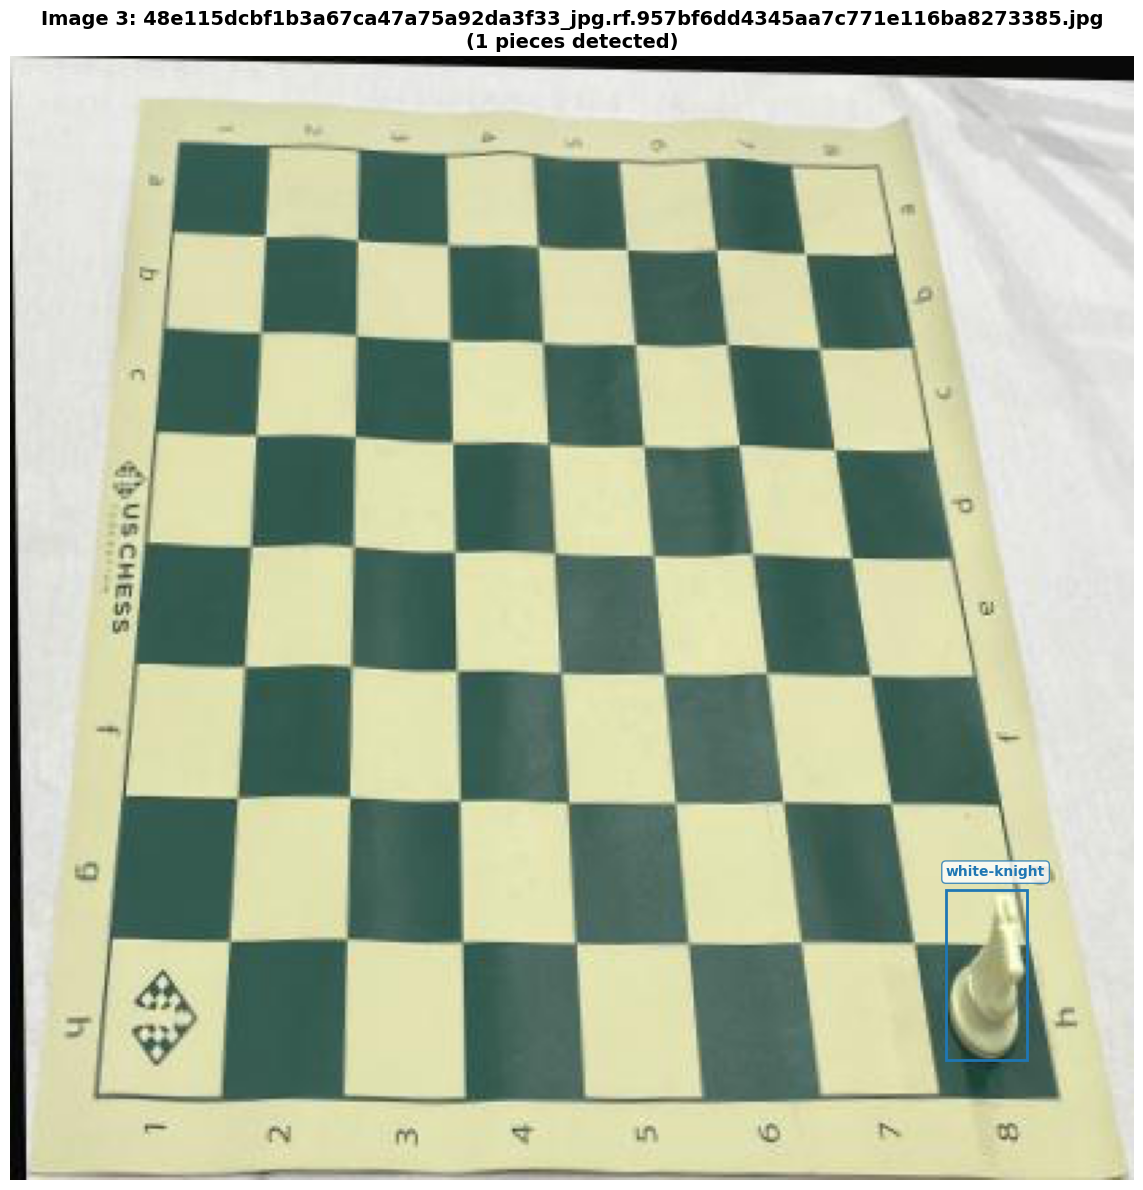

In [ ]:
# Visualize each selected image
for idx, image_filename in enumerate(selected_images, 1):
    # Get annotations for this image
    img_annotations = df_filtered[df_filtered['filename'] == image_filename].copy()

    # Construct full image path
    image_path = IMAGES_DIR / image_filename

    if not image_path.exists():
        print(f"Warning: Image not found: {image_path}")
        continue

    # Count annotations
    num_boxes = len(img_annotations)
    classes = img_annotations['class'].unique()

    print(f"\n{'='*60}")
    print(f"Image {idx}: {image_filename}")
    print(f"Number of bounding boxes: {num_boxes}")
    print(f"Classes present: {', '.join(sorted(classes))}")
    print(f"{'='*60}")

    # Draw and display
    fig = draw_bboxes_on_image(
        image_path,
        img_annotations,
        title=f"Image {idx}: {image_filename}\n({num_boxes} pieces detected)"
    )
    plt.show()